# Soccer Player Clustering

Grouping football players into playing styles using their skill attributes, without giving the model their actual position.

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.rcParams["figure.figsize"] = (8, 5)

## Load the data

In [3]:
DB_PATH = "database.sqlite"
conn = sqlite3.connect(DB_PATH)

attributes = pd.read_sql('''SELECT player_api_id, date, overall_rating, potential,
    finishing, marking, long_passing, volleys, standing_tackle, shot_power,
    short_passing, sliding_tackle, vision, gk_reflexes
FROM Player_Attributes''', conn)

players = pd.read_sql('''SELECT player_api_id, player_name FROM Player''', conn)
conn.close()

print("Player attribute records:", len(attributes))
print("Player records:", len(players))

Player attribute records: 183978
Player records: 11060


In [21]:
attributes.head()

,player_api_id,date,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision,gk_reflexes
0,505942,2016-02-18,67.0,71.0,44.0,65.0,64.0,44.0,69.0,55.0,61.0,69.0,54.0,8.0
1,505942,2015-11-19,67.0,71.0,44.0,65.0,64.0,44.0,69.0,55.0,61.0,69.0,54.0,8.0
2,505942,2015-09-21,62.0,66.0,44.0,65.0,64.0,44.0,66.0,55.0,61.0,69.0,54.0,8.0
3,505942,2015-03-20,61.0,65.0,43.0,62.0,63.0,43.0,63.0,54.0,60.0,66.0,53.0,7.0
4,505942,2007-02-22,61.0,65.0,43.0,62.0,63.0,43.0,63.0,54.0,60.0,66.0,53.0,7.0


Each player has several attribute records over time, so we just keep the latest one.

In [4]:
attributes["date"] = pd.to_datetime(attributes["date"])

latest_attributes = ( attributes .sort_values("date") .drop_duplicates("player_api_id", keep="last"))
df = latest_attributes.merge(players, on="player_api_id", how="left")
print("Number of unique players:", df["player_api_id"].nunique())
df.head()

Number of unique players: 11060


,player_api_id,date,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision,gk_reflexes,player_name
0,359194,2007-08-30,56.0,70.0,56.0,23.0,40.0,NaN,23.0,56.0,42.0,NaN,NaN,23.0,Quini
1,33688,2007-08-30,66.0,74.0,25.0,25.0,65.0,NaN,25.0,34.0,23.0,NaN,NaN,73.0,Jeremy Gavanon
2,30597,2008-08-30,68.0,76.0,56.0,47.0,73.0,NaN,44.0,62.0,74.0,NaN,NaN,22.0,Martijn Meerdink
3,26678,2008-08-30,59.0,64.0,31.0,59.0,47.0,NaN,62.0,44.0,55.0,NaN,NaN,24.0,Angelo Martha
4,97463,2008-08-30,67.0,69.0,61.0,70.0,59.0,NaN,67.0,65.0,63.0,NaN,NaN,25.0,Paulinho


In [5]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (11060, 15)

Missing values:
player_api_id        0
date                 0
overall_rating       3
potential            3
finishing            3
marking              3
long_passing         3
volleys            481
standing_tackle      3
shot_power           3
short_passing        3
sliding_tackle     481
vision             481
gk_reflexes          3
player_name          0
dtype: int64


## Clean the data

* Drop missing values.
* Remove goalkeepers: their skillset (diving, reflexes, handling) has nothing to do with the outfield skills we're clustering on. Keeping them in just creates a trivial "keeper vs everyone else" split instead of real playing styles.
* Keep players with overall_rating >= 70 and potential >= 65, to filter out weak/incomplete profiles while still keeping a large, varied set of players.

In [6]:
df = df.dropna().copy()
df = df[df["gk_reflexes"] < 50].copy()
df = df[(df["overall_rating"] >= 70) & (df["potential"] >= 65)].copy()
print("Players after filtering:", len(df))

Players after filtering: 3885


In [7]:
features = [ "finishing", "marking", "long_passing", "volleys", "standing_tackle", "shot_power", "short_passing", "sliding_tackle", "vision"]
X = df[features].copy()
X.describe().round(1)

,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
count,3885.0,3885.0,3885.0,3885.0,3885.0,3885.0,3885.0,3885.0,3885.0
mean,56.7,53.3,65.0,56.5,57.9,70.4,71.1,54.7,64.1
std,17.3,22.5,10.4,16.4,21.5,11.0,7.5,22.3,12.8
min,10.0,10.0,16.0,11.0,11.0,13.0,41.0,10.0,13.0
25%,44.0,30.0,59.0,45.0,37.0,65.0,67.0,32.0,57.0
50%,61.0,63.0,66.0,60.0,69.0,73.0,72.0,65.0,67.0
75%,71.0,73.0,73.0,69.0,76.0,78.0,76.0,74.0,73.0
max,95.0,90.0,93.0,92.0,91.0,95.0,93.0,95.0,94.0


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape after scaling:", X_scaled.shape)

Shape after scaling: (3885, 9)


In [9]:
k_values = range(2, 9)
baseline_silhouette = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    baseline_silhouette.append(score)

baseline_results = pd.DataFrame({"k": list(k_values), "silhouette_score": baseline_silhouette})
baseline_results.round(3)

,k,silhouette_score
0,2,0.371
1,3,0.363
2,4,0.295
3,5,0.252
4,6,0.212
5,7,0.207
6,8,0.185


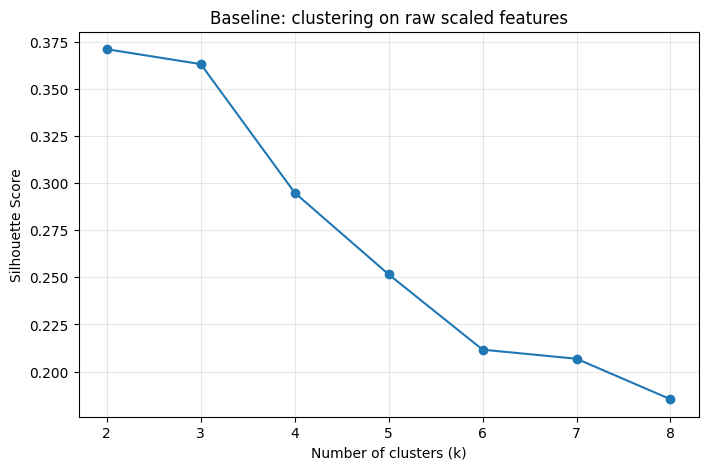

Best baseline k: 2, score: 0.371


In [10]:
plt.plot(baseline_results["k"], baseline_results["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Baseline: clustering on raw scaled features")
plt.grid(alpha=0.3)
plt.show()

best_baseline_k = int(baseline_results.loc[baseline_results["silhouette_score"].idxmax(), "k"])
best_baseline_score = baseline_results["silhouette_score"].max()
print(f"Best baseline k: {best_baseline_k}, score: {round(best_baseline_score, 3)}")

## PCA: how many components do we need?

In [11]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})
variance_table.round(3)

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.540,0.540
1,2,0.280,0.820
2,3,0.078,0.899
3,4,0.034,0.932
4,5,0.023,0.955
5,6,0.020,0.975
6,7,0.016,0.992
7,8,0.005,0.996
8,9,0.004,1.000


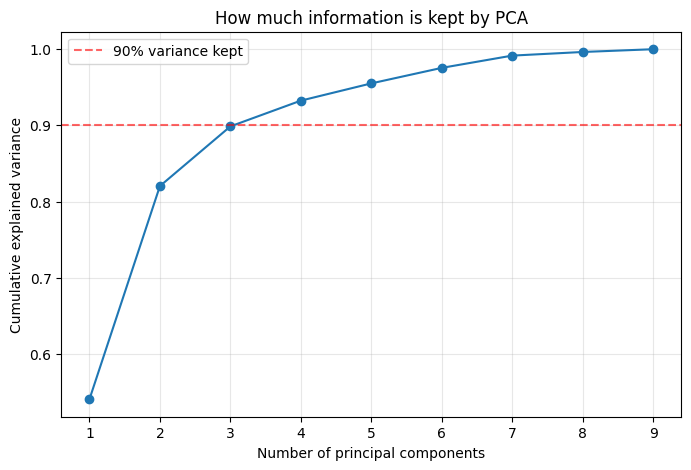

In [12]:
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.90, color="red", linestyle="--", alpha=0.6, label="90% variance kept")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("How much information is kept by PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Improved: cluster on the PCA components
Removes the overlap/noise between similar features (like the two tackle stats), which usually gives more separated clusters.

In [13]:
n_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components}")

pca_reduced = PCA(n_components=n_components, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)
print("Shape after PCA:", X_pca_reduced.shape)

Components needed for 90% variance: 4
Shape after PCA: (3885, 4)


In [14]:
improved_silhouette = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_pca_reduced)
    score = silhouette_score(X_pca_reduced, labels)
    improved_silhouette.append(score)

improved_results = pd.DataFrame({"k": list(k_values), "silhouette_score": improved_silhouette})
improved_results.round(3)

,k,silhouette_score
0,2,0.404
1,3,0.406
2,4,0.341
3,5,0.300
4,6,0.261
5,7,0.261
6,8,0.234


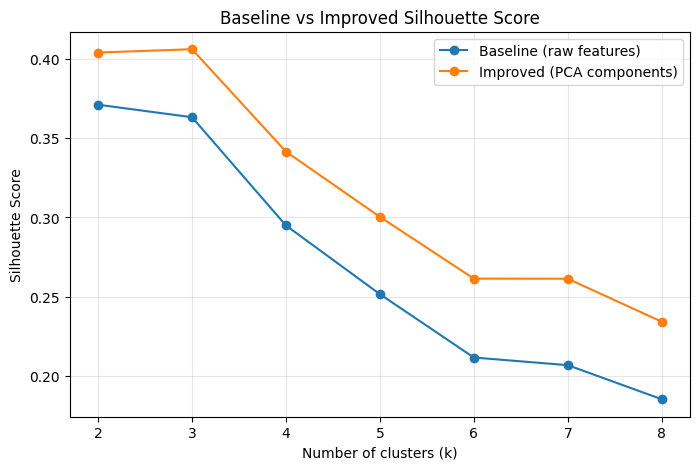

In [15]:
plt.plot(baseline_results["k"], baseline_results["silhouette_score"], marker="o", label="Baseline (raw features)")
plt.plot(improved_results["k"], improved_results["silhouette_score"], marker="o", label="Improved (PCA components)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Baseline vs Improved Silhouette Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

k = 2 scores the highest, but k = 3 is almost as good and splits players into clean attacker / defender / balanced groups (checked below), so we go with k = 3.

In [16]:
FINAL_K = 3

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_pca_reduced)

final_silhouette = silhouette_score(X_pca_reduced, df["cluster"])
print("Silhouette score:", round(final_silhouette, 3))
print("\nPlayers per cluster:")
print(df["cluster"].value_counts().sort_index())

Silhouette score: 0.406

Players per cluster:
cluster
0    1397
1    1430
2    1058
Name: count, dtype: int64


## Visualize the clusters (2D)

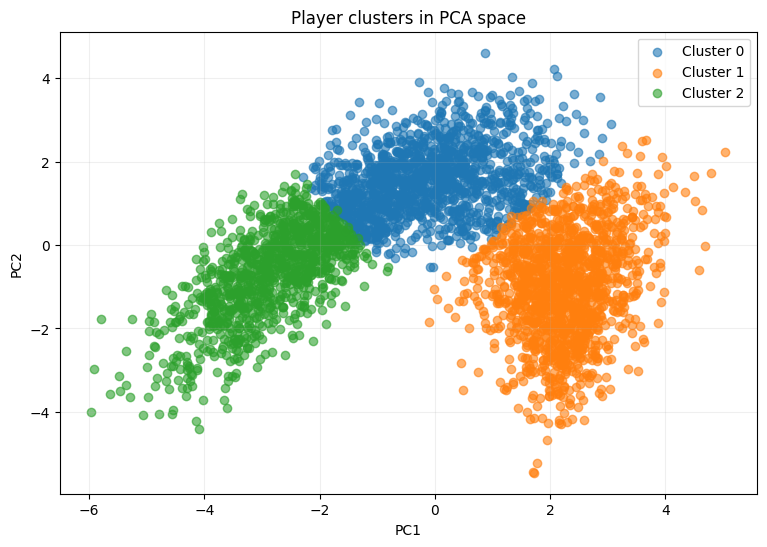

In [17]:
plt.figure(figsize=(9, 6))

for cluster in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster
    plt.scatter(X_pca_reduced[mask, 0], X_pca_reduced[mask, 1], label=f"Cluster {cluster}", alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Player clusters in PCA space")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Visualize the clusters (3D)

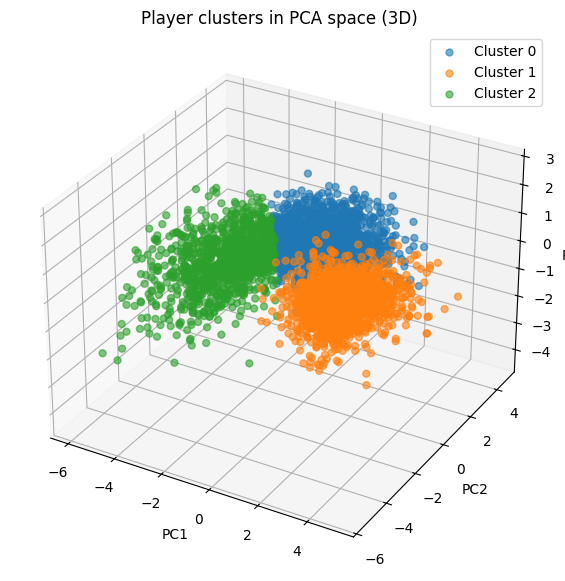

In [18]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster
    ax.scatter(
        X_pca_reduced[mask, 0],
        X_pca_reduced[mask, 1],
        X_pca_reduced[mask, 2],
        label=f"Cluster {cluster}",
        alpha=0.6,
        s=25
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Player clusters in PCA space (3D)")
ax.legend()
plt.show()

In [19]:
#Average skill values per cluster, using the original features so they're easy to read.
cluster_profile = df.groupby("cluster")[features].mean()
cluster_profile.round(1)

,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
cluster,,,,,,,,,
0,57.9,64.6,73.3,59.6,70.4,74.3,76.4,67.2,71.2
1,71.8,26.6,60.1,68.6,32.1,74.8,70.5,28.2,68.4
2,34.6,74.3,60.7,36.2,76.2,59.4,64.9,74.1,49.0


## Sample players from each cluster

In [20]:
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 40)
    top_players = df[df["cluster"] == cluster].sort_values("overall_rating", ascending=False)
    display(top_players[["player_name", "overall_rating", "potential"] + features].head(8))


Cluster 0
----------------------------------------


,player_name,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
4800,Andres Iniesta,88.0,88.0,73.0,57.0,86.0,74.0,57.0,65.0,92.0,56.0,92.0
4236,Thiago Silva,88.0,88.0,38.0,90.0,81.0,63.0,91.0,78.0,79.0,89.0,74.0
4790,Luka Modric,87.0,87.0,71.0,69.0,83.0,75.0,75.0,73.0,86.0,73.0,89.0
5722,Toni Kroos,87.0,89.0,76.0,60.0,90.0,82.0,72.0,87.0,89.0,59.0,88.0
7801,Sergio Ramos,87.0,87.0,60.0,85.0,70.0,66.0,89.0,77.0,76.0,90.0,63.0
9262,Gareth Bale,87.0,89.0,81.0,60.0,80.0,76.0,65.0,87.0,84.0,62.0,77.0
5663,Jerome Boateng,87.0,88.0,34.0,84.0,81.0,53.0,90.0,79.0,75.0,91.0,74.0
5966,Philipp Lahm,87.0,87.0,47.0,86.0,79.0,66.0,87.0,57.0,86.0,95.0,83.0



Cluster 1
----------------------------------------


,player_name,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
5392,Lionel Messi,94.0,94.0,93.0,13.0,79.0,85.0,23.0,80.0,88.0,21.0,90.0
4751,Cristiano Ronaldo,93.0,93.0,95.0,22.0,72.0,87.0,31.0,94.0,81.0,23.0,81.0
4788,Luis Suarez,90.0,90.0,90.0,30.0,64.0,87.0,45.0,88.0,82.0,38.0,84.0
6098,Neymar,90.0,94.0,88.0,21.0,74.0,83.0,24.0,78.0,78.0,33.0,79.0
5879,Arjen Robben,89.0,89.0,85.0,29.0,73.0,86.0,26.0,86.0,85.0,26.0,84.0
4543,Zlatan Ibrahimovic,89.0,89.0,90.0,15.0,76.0,92.0,41.0,93.0,84.0,27.0,83.0
6009,Eden Hazard,88.0,90.0,81.0,25.0,82.0,79.0,27.0,79.0,85.0,22.0,86.0
6390,Mesut Oezil,88.0,89.0,75.0,22.0,84.0,77.0,16.0,70.0,89.0,19.0,93.0



Cluster 2
----------------------------------------


,player_name,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
5948,Diego Godin,86.0,86.0,42.0,86.0,69.0,47.0,86.0,67.0,77.0,89.0,52.0
9825,Giorgio Chiellini,86.0,86.0,33.0,90.0,49.0,45.0,90.0,79.0,49.0,90.0,46.0
10171,Miranda,85.0,85.0,43.0,89.0,65.0,51.0,90.0,70.0,64.0,89.0,53.0
6875,Vincent Kompany,85.0,85.0,45.0,86.0,66.0,46.0,90.0,76.0,65.0,87.0,59.0
10481,Andrea Barzagli,85.0,85.0,27.0,90.0,65.0,35.0,90.0,51.0,65.0,88.0,50.0
6079,Nicolas Otamendi,84.0,84.0,53.0,83.0,66.0,56.0,86.0,69.0,64.0,86.0,45.0
6377,Laurent Koscielny,84.0,84.0,32.0,83.0,67.0,35.0,87.0,54.0,75.0,85.0,56.0
6793,John Terry,84.0,84.0,46.0,87.0,64.0,55.0,87.0,61.0,66.0,84.0,59.0


## Conclusion

* **Cluster 0 — Balanced / Playmakers**: decent values across passing, vision and defense, without being extreme in one direction. Iniesta, Thiago Silva, Kroos.
* **Cluster 1 — Attackers**: high finishing and shot power, low tackling/marking. Messi, Ronaldo, Neymar, Suarez.
* **Cluster 2 — Defenders**: high marking and tackling, low finishing. Godin, Chiellini, Kompany.

The model never saw any player's position — these groups came purely from clustering skill attributes, and they still line up closely with real playing styles.